<a href="https://colab.research.google.com/github/melissanespeque/data-reuploading-classifier/blob/main/IRIS_classical_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

SVM Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00      

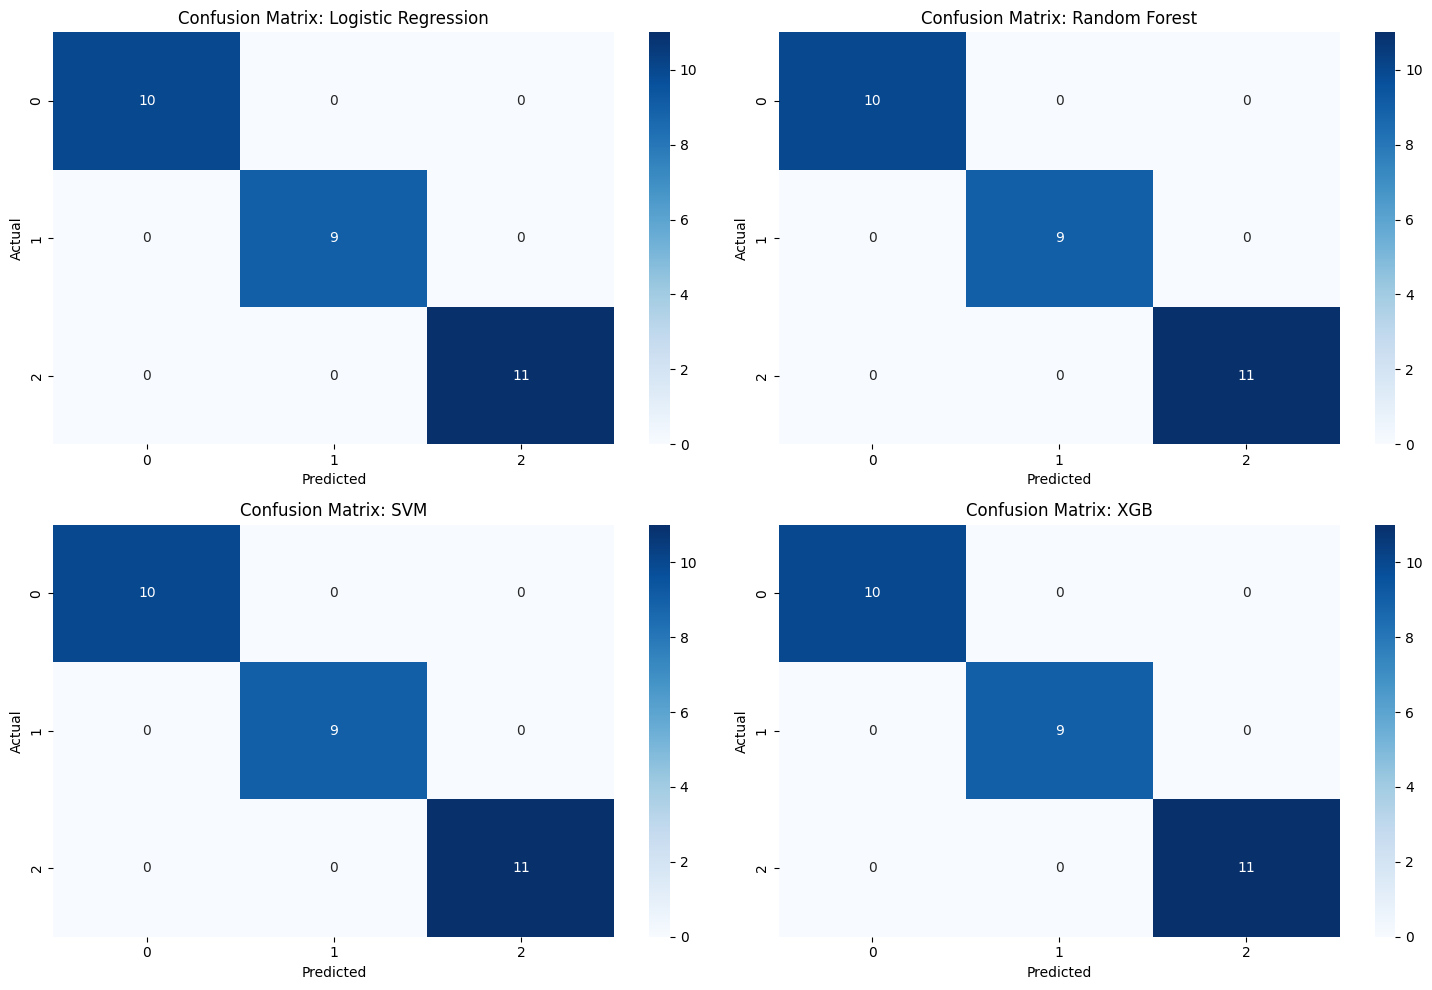

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset (Iris dataset)
from sklearn.datasets import load_iris
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Split dataset
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Features Selection
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# Train Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Train Support Vector Machine (SVM) Model
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# Train XGB
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective='multi:softprob',
    random_state=42
)
model.fit(X_train, y_train)
y_pred_xgb = model.predict(X_test)
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Plot Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # Adjusted figsize for 2x2 grid
models = {'Logistic Regression': y_pred_log, 'Random Forest': y_pred_rf, 'SVM': y_pred_svm, 'XGB': y_pred_xgb}
for i, (model_name, y_pred) in enumerate(models.items()):
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes.flatten()[i]) # Flatten axes for correct indexing
    axes.flatten()[i].set_title(f'Confusion Matrix: {model_name}')
    axes.flatten()[i].set_xlabel('Predicted')
    axes.flatten()[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
def circle(samples, random_seed=42):
    np.random.seed(random_seed)
    centers = np.array([[0, 0]])
    radii = np.array([np.sqrt(2/np.pi)]) #def radius so it represents 0.5 the area of the square - should be a balanced dataset in classification
    data=[]
    dim = 2
    for i in range(samples):
        x = 2 * (np.random.rand(dim)) - 1 #so that every point its inside the squared limit (-1,1)
        #random.rand = create an array of the given shape and populate it with random samples from a uniform distribution over [0, 1)
        y = 0
        for c, r in zip(centers, radii):
            if np.linalg.norm(x - c) < r: #calculates distance between point and center to classify if inside the circle or not
                y = 1

        data.append([x, y])

    return data, (centers, radii)

In [ ]:
cir, (c,r)= circle(50)

### Applying Logistic Regression to the Circle Dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define cir here to ensure it's available
cir, (c,r)= circle(50)

# Convert cir data to DataFrame
circle_df = pd.DataFrame([item[0].tolist() + [item[1]] for item in cir], columns=['feature_1', 'feature_2', 'target'])

# Split dataset
X_circle = circle_df[['feature_1', 'feature_2']]
y_circle = circle_df['target']
X_train_circle, X_test_circle, y_train_c, y_test_c = train_test_split(X_circle, y_circle, test_size=0.2, random_state=42)

# Features Scaling
scaler_circle = StandardScaler()
X_train_cs = scaler_circle.fit_transform(X_train_circle)
X_test_cs = scaler_circle.transform(X_test_circle)

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train_cs, y_train_c)
y_pred_log = log_reg.predict(X_test_cs)
print("Logistic Regression Accuracy:", accuracy_score(y_test_c, y_pred_log))
print(classification_report(y_test_c, y_pred_log))

# Train Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_cs, y_train_c)
y_pred_rf = rf.predict(X_test_cs)
print("Random Forest Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print(classification_report(y_test_c, y_pred_rf))

# Train Support Vector Machine (SVM) Model
svm = SVC(kernel='rbf')
svm.fit(X_train_cs, y_train_c)
y_pred_svm = svm.predict(X_test_cs)
print("SVM Accuracy:", accuracy_score(y_test_c, y_pred_svm))
print(classification_report(y_test_c, y_pred_svm))

# Train XGB
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective='multi:softprob',
    num_class=len(np.unique(y_train_c)), # Set num_class for multi:softprob
    random_state=42
)
model.fit(X_train_cs, y_train_c)
y_pred_xgb = model.predict(X_test_cs) # Predict using scaled test data
print("XGB Accuracy:", accuracy_score(y_test_c, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_xgb))

# Plot Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # Adjusted figsize for 2x2 grid
models = {'Logistic Regression': y_pred_log, 'Random Forest': y_pred_rf, 'SVM': y_pred_svm, 'XGB': y_pred_xgb}
for i, (model_name, y_pred) in enumerate(models.items()):
    sns.heatmap(confusion_matrix(y_test_c, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes.flatten()[i]) # Flatten axes for correct indexing
    axes.flatten()[i].set_title(f'Confusion Matrix: {model_name}')
    axes.flatten()[i].set_xlabel('Predicted')
    axes.flatten()[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

Logistic Regression Accuracy: 0.4
              precision    recall  f1-score   support

           0       0.40      0.40      0.40         5
           1       0.40      0.40      0.40         5

    accuracy                           0.40        10
   macro avg       0.40      0.40      0.40        10
weighted avg       0.40      0.40      0.40        10

Random Forest Accuracy: 0.7
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.62      1.00      0.77         5

    accuracy                           0.70        10
   macro avg       0.81      0.70      0.67        10
weighted avg       0.81      0.70      0.67        10

SVM Accuracy: 0.8
              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.71      1.00      0.83         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79     

ValueError: Classification metrics can't handle a mix of binary and multilabel-indicator targets